<a href="https://colab.research.google.com/github/rubenchov/aprendizajeautomaticovision/blob/main/IntroML_5_IrisLogit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **REGRESIÓN LOGÍSTICA**

La fórmula de una regresión logística predice una probabilidad generando valores entre 0 y 1 utilizando la función sigmoide (o logística):

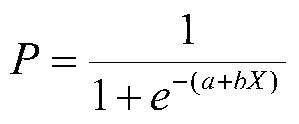

Importar librerías

In [34]:
import numpy as np
import matplotlib.pyplot as plt

Generar gráfica de la función logística con diferentes valores de media (mean) y forma (shape)

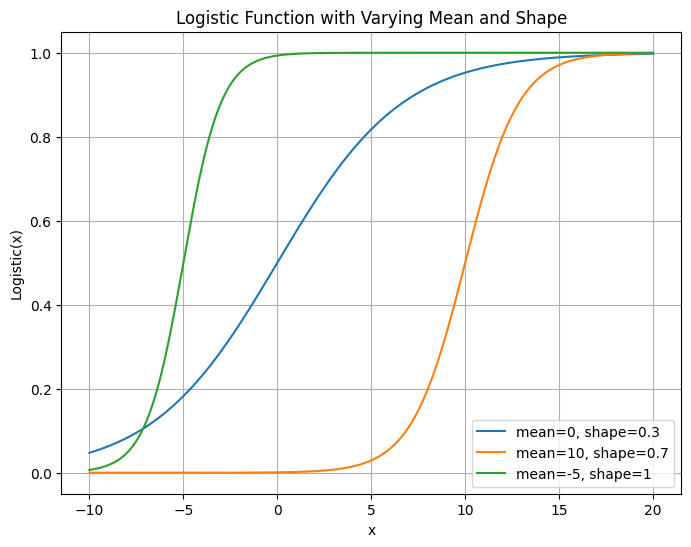

In [35]:
# Generate x values
x = np.linspace(-10, 20, 400)

# Different mean and shape combinations
means = [0, 10, -5] #Change for different values of mean
shapes = [0.3, 0.7, 1] #Change for different values of shape

# Plot
plt.figure(figsize=(8, 6))
for mean, shape in zip(means, shapes):
    #y = logistic_function(x, mean, shape)
    y = 1 / (1 + np.exp(-shape * (x - mean)))
    plt.plot(x, y, label=f'mean={mean}, shape={shape}')

plt.xlabel("x")
plt.ylabel("Logistic(x)")
plt.title("Logistic Function with Varying Mean and Shape")
plt.legend()
plt.grid(True)
plt.show()

En el anterior código se recomienda probar con diferentes valores de media y forma para generar y entender las variaciones que puede tener un ajuste de una función sigmoidal

## Entrenamiento de la función logística

Importar librerías

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris #Conjunto de datos Iris
from sklearn.model_selection import train_test_split #Para partición del conjunto de datos en entrenamiento y prueba
from sklearn.preprocessing import LabelEncoder #Para convertir etiquetas
from sklearn.metrics import accuracy_score #Para calcular exactitud
from sklearn.metrics import ConfusionMatrixDisplay #Matriz de confusión (para validación)
import pandas as pd

Importar conjunto de datos Iris

In [37]:
#Cargar conjunto de datos
iris = load_iris()

#Convertir a pandas (dataframe - df)
iris_features = pd.DataFrame(data=iris.data, columns=iris.feature_names) #Características X

Codificado de etiquetas

In [38]:
le = LabelEncoder()
encod = le.fit_transform(iris.target_names)

Definir conjunto de datos y partir en entrenamiento y validación

In [39]:
X = iris_features
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.33, random_state=101)

Definición del modelo y entrenamiento

In [40]:
logit = LogisticRegression() #Sin hiperparámetros, se recomienda añadir y modificar
logit.fit(X_train, y_train)

LogisticRegression()

Predecir sobre el subconjunto de prueba

In [41]:
pred = logit.predict(X_test)
print(pred)

[0 0 0 2 1 2 1 1 2 0 2 0 0 2 2 1 1 1 0 2 1 0 1 1 1 1 1 2 0 0 2 1 2 1 2 1 1
 1 1 2 0 0 0 2 1 0 2 1 0 1]


Decodificación

In [42]:
pred_labels = le.inverse_transform(np.round(pred).astype(int))
actual_labels = le.inverse_transform(y_test)
results = np.array([pred_labels, actual_labels])
results_df = pd.DataFrame(results.T, columns=['Predicted (logistic regression)', 'Actual (Ground-Truth)'])
print(results_df)

   Predicted (logistic regression) Actual (Ground-Truth)
0                           setosa                setosa
1                           setosa                setosa
2                           setosa                setosa
3                        virginica             virginica
4                       versicolor            versicolor
5                        virginica             virginica
6                       versicolor            versicolor
7                       versicolor            versicolor
8                        virginica             virginica
9                           setosa                setosa
10                       virginica             virginica
11                          setosa                setosa
12                          setosa                setosa
13                       virginica             virginica
14                       virginica             virginica
15                      versicolor            versicolor
16                      versico

Cálculo de la exactitud

In [43]:
accuracy = accuracy_score(y_test, pred.round())
print("Exactitud:", accuracy)

Exactitud: 0.98


Calcular y mostrar matriz de confusión

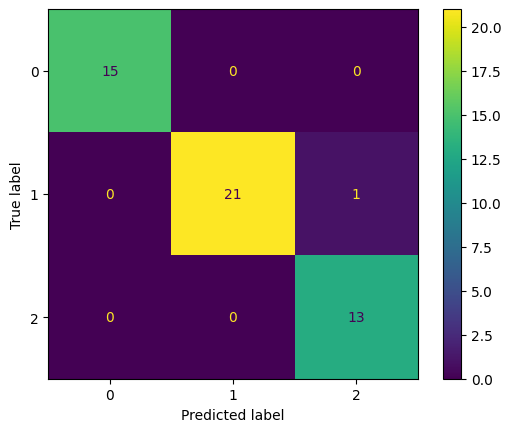

In [44]:
ConfusionMatrixDisplay.from_predictions(y_test, pred)

Análisis: se muestra una diagonal con casi la totalidad de las muestras del subconjunto de validación con una clasificación perfecta, excepto con una muestra que era de la clase 1 y la predijo como clase 2.